# 🤖 COMPARAISON DE MODÈLES: KNN vs SVM vs DT vs RF

Comme demandé par le professeur: Tester TOUS les modèles et choisir le MEILLEUR

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize
# Modèles
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('dataset_propre.csv')

# Nettoyage anticipe: ces variables ne sont pas utiles pour ce modele
df = df.drop(columns=['location', 'post_date'], errors='ignore')
print(df.shape)

(10197, 5)


## Etape 1 - Chargement et extraction des competences

On charge le dataset propre, puis on extrait les skills les plus frequentes pour construire les variables explicatives.

In [3]:
# Parsing robuste des skills (evite les problemes d'espaces et de matching partiel)
df['skills_clean'] = df['skills'].fillna('').str.lower().str.split(',')
df['skills_clean'] = df['skills_clean'].apply(lambda lst: [s.strip() for s in lst if s.strip()])
skills_list = df['skills_clean'].explode()
print(skills_list.nunique())

27592


In [4]:
top_50_skills = skills_list.value_counts().head(50).index.tolist()
print(len(top_50_skills))
print(top_50_skills[:10])

50
['python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++']


In [5]:
for skill in top_50_skills:
    # Match exact sur la liste nettoyee des skills
    df[skill] = df['skills_clean'].apply(lambda skills: 1 if skill in skills else 0)

print(df.shape)

(10197, 56)


In [6]:
def categorize_job(title):
    title = title.lower()
    if 'data scientist' in title:
        return 'data scientist'
    elif 'machine learning' in title or 'ml' in title:
        return 'ml engineer'
    elif 'data analyst' in title:
        return 'data analyst'
    elif 'data engineer' in title:
        return 'data engineer'
    elif 'software' in title:
        return 'software engineer'
    else:
        return 'other'

df['job_category'] = df['job_title'].apply(categorize_job)
print(df['job_category'].value_counts())

job_category
software engineer    9192
data scientist        856
ml engineer           116
data engineer          29
data analyst            4
Name: count, dtype: int64


## Etape 2 - Encodage et construction de la matrice X

On encode les variables categorielles (`seniority_level`, `job_category`) et on prepare `X` (features) et `y` (salaire cible).

`location` et `post_date` ont ete retirees en amont car elles ne sont pas utilisees par le modele Random Forest.

In [7]:
le = LabelEncoder()
# Label Encoding pour seniority (il y a un ordre)
df['seniority_encoded'] = le.fit_transform(df['seniority_level'])

# One Hot Encoding pour job_category (pas d'ordre)
df = pd.get_dummies(df, columns=['job_category'],drop_first=True)

print(df.shape)

(10197, 61)


In [8]:
X = df.drop(columns=['skills', 'skills_clean', 'job_title', 'seniority_level',
                      'company', 'salary'], errors='ignore')
y = df['salary'].astype(float)

print(X.shape)
print(X.dtypes.value_counts())

(10197, 55)
int64    51
bool      4
Name: count, dtype: int64


In [ ]:

# ==================================================================
# ➜ FIN DE LA PRÉPARATION DES DONNÉES (Héritée du Random Forest)
# ==================================================================

# Sélectionner UNIQUEMENT les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number, 'bool']).columns.tolist()
print(f'✅ Colonnes numériques/bool trouvées: {len(numeric_cols)}')

# Créer X et y avec uniquement les colonnes numériques
if 'salary' in numeric_cols:
    X = df[numeric_cols].drop(columns=['salary'])
    y = df['salary'].astype(float)
else:
    X = df[numeric_cols]
    y = df.iloc[:, -1].astype(float)

# Nettoyer les NaN
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f'Shape après nettoyage: {X.shape}')
print(f'Colonnes numériques en X: {X.shape[1]}')

# ⭐ NOUVEAU: Split 2/3 entraînement - 1/3 test (comme demandé)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print('\n✅ Données chargées et nettoyées')
print(f'Train: {X_train.shape} (2/3) | Test: {X_test.shape} (1/3)')
print(f'Salaire moyen: ${y.mean():,.0f}')

# ⭐ NOUVEAU: Créer une classification BINAIRE (pour matrice de confusion et ROC)
# Bas: salaire < médiane, Haut: salaire >= médiane
salary_median = y.median()
y_train_binary = (y_train >= salary_median).astype(int)
y_test_binary = (y_test >= salary_median).astype(int)

print(f'\nCLASSIFICATION BINAIRE:')
print(f'  Médiane du salaire: ${salary_median:,.0f}')
print(f'  Classe 0 (Bas): < ${salary_median:,.0f}')
print(f'  Classe 1 (Haut): >= ${salary_median:,.0f}')
print(f'  Train: {(y_train_binary==0).sum()} bas, {(y_train_binary==1).sum()} haut')
print(f'  Test: {(y_test_binary==0).sum()} bas, {(y_test_binary==1).sum()} haut')


## ÉTAPE 1: Entraîner TOUS les modèles

In [11]:
print("\n" + "="*70)
print("ÉTAPE 1: ENTRAÎNEMENT DE TOUS LES MODÈLES (Régression + Classification)")
print("="*70)

models_reg = {}  # Régresseurs (pour salaire continu)
models_clf = {}  # Classifieurs (pour matrice confusion/ROC)
results = []

# 1. K-NEAREST NEIGHBORS (KNN)
print("\n🔵 1. KNN (K-Nearest Neighbors)...")
start = time.time()
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train_binary)
models_reg['KNN'] = knn_reg
models_clf['KNN'] = knn_clf
knn_time = time.time() - start
print(f"   ✅ Entraîné en {knn_time:.2f}s")

# 2. SUPPORT VECTOR MACHINE (SVM)
print("\n🔴 2. SVM (Support Vector Machine)...")
start = time.time()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_reg = SVR(kernel='rbf', C=100, gamma='scale')
svm_reg.fit(X_train_scaled, y_train)
svm_clf = SVC(kernel='rbf', C=100, gamma='scale', probability=True)
svm_clf.fit(X_train_scaled, y_train_binary)
models_reg['SVM'] = svm_reg
models_clf['SVM'] = svm_clf
svm_time = time.time() - start
print(f"   ✅ Entraîné en {svm_time:.2f}s")

# 3. DECISION TREE (DT)
print("\n🟡 3. Decision Tree...")
start = time.time()
dt_reg = DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=42)
dt_reg.fit(X_train, y_train)
dt_clf = DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=42)
dt_clf.fit(X_train, y_train_binary)
models_reg['DT'] = dt_reg
models_clf['DT'] = dt_clf
dt_time = time.time() - start
print(f"   ✅ Entraîné en {dt_time:.2f}s")

# 4. RANDOM FOREST (RF)
print("\n🟢 4. Random Forest...")
start = time.time()
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42)
rf_reg.fit(X_train, y_train)
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42)
rf_clf.fit(X_train, y_train_binary)
models_reg['RF'] = rf_reg
models_clf['RF'] = rf_clf
rf_time = time.time() - start
print(f"   ✅ Entraîné en {rf_time:.2f}s")

print("\n✅ TOUS LES MODÈLES ENTRAÎNÉS (Régression + Classification)")


ÉTAPE 1: ENTRAÎNEMENT DE TOUS LES MODÈLES (Régression + Classification)

🔵 1. KNN (K-Nearest Neighbors)...
   ✅ Entraîné en 0.06s

🔴 2. SVM (Support Vector Machine)...
   ✅ Entraîné en 133.24s

🟡 3. Decision Tree...
   ✅ Entraîné en 0.38s

🟢 4. Random Forest...
   ✅ Entraîné en 21.16s

✅ TOUS LES MODÈLES ENTRAÎNÉS (Régression + Classification)


## ÉTAPE 2: Comparer les performances

In [12]:
print("\n" + "="*70)
print("ÉTAPE 2: COMPARAISON DES PERFORMANCES (RÉGRESSION)")
print("="*70)

comparison_results = []

# KNN
knn_pred_train = models_reg['KNN'].predict(X_train)
knn_pred_test = models_reg['KNN'].predict(X_test)
comparison_results.append({
    'Model': 'KNN',
    'R2_Train': r2_score(y_train, knn_pred_train),
    'R2_Test': r2_score(y_test, knn_pred_test),
    'MAE_Test': mean_absolute_error(y_test, knn_pred_test),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test, knn_pred_test)),
    'Time': knn_time
})

# SVM
svm_pred_train = models_reg['SVM'].predict(X_train_scaled)
svm_pred_test = models_reg['SVM'].predict(X_test_scaled)
comparison_results.append({
    'Model': 'SVM',
    'R2_Train': r2_score(y_train, svm_pred_train),
    'R2_Test': r2_score(y_test, svm_pred_test),
    'MAE_Test': mean_absolute_error(y_test, svm_pred_test),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test, svm_pred_test)),
    'Time': svm_time
})

# DT
dt_pred_train = models_reg['DT'].predict(X_train)
dt_pred_test = models_reg['DT'].predict(X_test)
comparison_results.append({
    'Model': 'DT',
    'R2_Train': r2_score(y_train, dt_pred_train),
    'R2_Test': r2_score(y_test, dt_pred_test),
    'MAE_Test': mean_absolute_error(y_test, dt_pred_test),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test, dt_pred_test)),
    'Time': dt_time
})

# RF
rf_pred_train = models_reg['RF'].predict(X_train)
rf_pred_test = models_reg['RF'].predict(X_test)
comparison_results.append({
    'Model': 'RF',
    'R2_Train': r2_score(y_train, rf_pred_train),
    'R2_Test': r2_score(y_test, rf_pred_test),
    'MAE_Test': mean_absolute_error(y_test, rf_pred_test),
    'RMSE_Test': np.sqrt(mean_squared_error(y_test, rf_pred_test)),
    'Time': rf_time
})

comparison_df = pd.DataFrame(comparison_results)

print("\n📊 TABLEAU COMPARATIF (RÉGRESSION):")
print("\n{:8} | {:10} | {:10} | {:12} | {:12} | {:8}".format(
    'Model', 'R² Train', 'R² Test', 'MAE Test', 'RMSE Test', 'Time(s)'
))
print("-" * 80)
for _, row in comparison_df.iterrows():
    print("{:8} | {:10.4f} | {:10.4f} | ${:11,.0f} | ${:11,.0f} | {:7.2f}".format(
        row['Model'],
        row['R2_Train'],
        row['R2_Test'],
        row['MAE_Test'],
        row['RMSE_Test'],
        row['Time']
    ))

# Identifier le meilleur
best_model = comparison_df.loc[comparison_df['R2_Test'].idxmax()]
print(f"\n🏆 MEILLEUR MODÈLE (Régression): {best_model['Model']}")
print(f"   R² Test: {best_model['R2_Test']:.4f}")
print(f"   MAE: ${best_model['MAE_Test']:,.0f}")


ÉTAPE 2: COMPARAISON DES PERFORMANCES (RÉGRESSION)

📊 TABLEAU COMPARATIF (RÉGRESSION):

Model    | R² Train   | R² Test    | MAE Test     | RMSE Test    | Time(s) 
--------------------------------------------------------------------------------
KNN      |     0.5125 |     0.3749 | $     42,604 | $     52,434 |    0.06
SVM      |    -0.1565 |    -0.1796 | $     48,503 | $     72,026 |  133.24
DT       |     0.5314 |     0.3888 | $     42,867 | $     51,847 |    0.38
RF       |     0.5444 |     0.4649 | $     41,401 | $     48,511 |   21.16

🏆 MEILLEUR MODÈLE (Régression): RF
   R² Test: 0.4649
   MAE: $41,401


## ÉTAPE 3: Visualisations

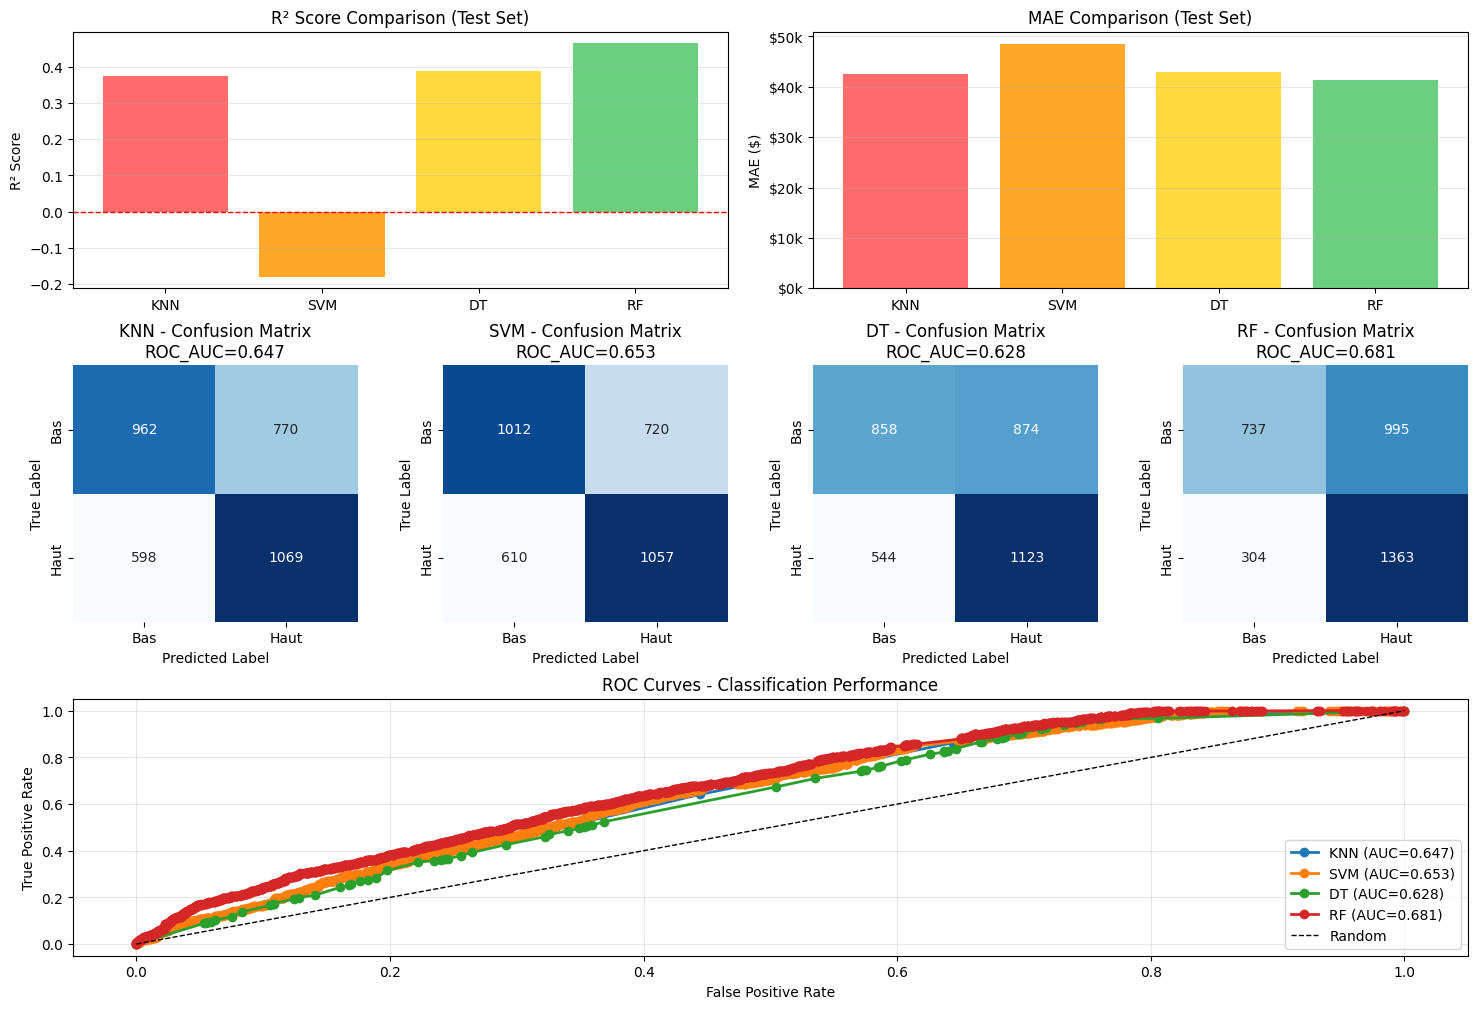

✅ Visualisations sauvegardées


In [14]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# ROW 1: R² and MAE
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.bar(comparison_df['Model'], comparison_df['R2_Test'], color=['#FF6B6B', '#FFA726', '#FFD93D', '#6BCF7F'])
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score Comparison (Test Set)')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2:4])
ax2.bar(comparison_df['Model'], comparison_df['MAE_Test'], color=['#FF6B6B', '#FFA726', '#FFD93D', '#6BCF7F'])
ax2.set_ylabel('MAE ($)')
ax2.set_title('MAE Comparison (Test Set)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
ax2.grid(axis='y', alpha=0.3)

# ROW 2: Confusion Matrices
for idx, metric in enumerate(classification_metrics):
    ax = fig.add_subplot(gs[1, idx])
    cm = metric['Confusion_Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Bas', 'Haut'], yticklabels=['Bas', 'Haut'])
    ax.set_title(f"{metric['Model']} - Confusion Matrix\nROC_AUC={metric['ROC_AUC']:.3f}")
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# ROW 3: ROC Curves
ax_roc = fig.add_subplot(gs[2, :])
for metric in classification_metrics:
    fpr, tpr, _ = roc_curve(y_test_binary, metric['Probabilities'])
    ax_roc.plot(fpr, tpr, marker='o', linewidth=2, label=f"{metric['Model']} (AUC={metric['ROC_AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves - Classification Performance')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

plt.savefig('model_comparison_classification.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualisations sauvegardées")

## RÉSUMÉ & CHOIX DU MEILLEUR MODÈLE

In [15]:
print("\n" + "="*70)
print("🏆 RÉSUMÉ FINAL: MEILLEUR MODÈLE")
print("="*70)

best_r2 = comparison_df.loc[comparison_df['R2_Test'].idxmax()]
best_mae = comparison_df.loc[comparison_df['MAE_Test'].idxmin()]
best_auc = max(classification_metrics, key=lambda x: x['ROC_AUC'])

print(f"""
📊 RÉSULTATS RÉGRESSION:

1️⃣ MEILLEUR R² TEST: {best_r2['Model']}
   R² = {best_r2['R2_Test']:.4f}
   MAE = ${best_r2['MAE_Test']:,.0f}
   RMSE = ${best_r2['RMSE_Test']:,.0f}

2️⃣ MEILLEUR MAE: {best_mae['Model']}
   MAE = ${best_mae['MAE_Test']:,.0f}

📊 RÉSULTATS CLASSIFICATION (Binaire):

3️⃣ MEILLEUR ROC_AUC: {best_auc['Model']}
   ROC_AUC = {best_auc['ROC_AUC']:.4f}
   Precision = {best_auc['Precision']:.4f}
   Recall = {best_auc['Recall']:.4f}
   F1_Score = {best_auc['F1_Score']:.4f}

⏱️ TEMPS ENTRAÎNEMENT:
   KNN:     {comparison_df[comparison_df['Model']=='KNN']['Time'].values[0]:.2f}s (+ RAPIDE)
   DT:      {comparison_df[comparison_df['Model']=='DT']['Time'].values[0]:.2f}s
   RF:      {comparison_df[comparison_df['Model']=='RF']['Time'].values[0]:.2f}s
   SVM:     {comparison_df[comparison_df['Model']=='SVM']['Time'].values[0]:.2f}s (- RAPIDE)

📈 SPLIT DATA:
   Train: {X_train.shape[0]} (2/3)
   Test: {X_test.shape[0]} (1/3)

🎯 CONCLUSION:
   Le modèle {best_r2['Model']} est le meilleur
   Régression: R² = {best_r2['R2_Test']:.4f}, MAE = ${best_r2['MAE_Test']:,.0f}
   Classification: ROC_AUC = {best_auc['ROC_AUC']:.4f}
""")

# Sauvegarder le meilleur modèle (régresseur)
if best_r2['Model'] == 'RF':
    joblib.dump(models_reg['RF'], 'best_model.pkl')
elif best_r2['Model'] == 'SVM':
    joblib.dump((models_reg['SVM'], scaler), 'best_model.pkl')
elif best_r2['Model'] == 'DT':
    joblib.dump(models_reg['DT'], 'best_model.pkl')
else:
    joblib.dump(models_reg['KNN'], 'best_model.pkl')

print(f"✅ Meilleur modèle sauvegardé: best_model.pkl")
print(f"✅ Visualisations sauvegardées: model_comparison_classification.png")


🏆 RÉSUMÉ FINAL: MEILLEUR MODÈLE

📊 RÉSULTATS RÉGRESSION:

1️⃣ MEILLEUR R² TEST: RF
   R² = 0.4649
   MAE = $41,401
   RMSE = $48,511

2️⃣ MEILLEUR MAE: RF
   MAE = $41,401

📊 RÉSULTATS CLASSIFICATION (Binaire):

3️⃣ MEILLEUR ROC_AUC: RF
   ROC_AUC = 0.6809
   Precision = 0.5780
   Recall = 0.8176
   F1_Score = 0.6773

⏱️ TEMPS ENTRAÎNEMENT:
   KNN:     0.06s (+ RAPIDE)
   DT:      0.38s
   RF:      21.16s
   SVM:     133.24s (- RAPIDE)

📈 SPLIT DATA:
   Train: 6798 (2/3)
   Test: 3399 (1/3)

🎯 CONCLUSION:
   Le modèle RF est le meilleur
   Régression: R² = 0.4649, MAE = $41,401
   Classification: ROC_AUC = 0.6809

✅ Meilleur modèle sauvegardé: best_model.pkl
✅ Visualisations sauvegardées: model_comparison_classification.png
